In [ ]:
# Data Source: https://www.kaggle.com/kaggle/world-development-indicators

# Matplotlib: Exploring Data Visualization</p><br>


This week, we will be using an open dataset from <a href="https://www.kaggle.com">Kaggle</a>. It is  <a href="https://www.kaggle.com/kaggle/world-development-indicators">The World Development Indicators</a> dataset obtained from the World Bank containing over a thousand annual indicators of economic development from hundreds of countries around the world.
<br>
<br>
This is a slightly modified version of the original dataset from <a href="http://data.worldbank.org/data-catalog/world-development-indicators">The World Bank</a>
<br>
<br>
List of the <a href="https://data.worldbank.org/indicator">available indicators</a> and a <a href="https://data.worldbank.org/country">list of the available countries</a>.
</td>
</tr>
</table>

# Step 1: Initial exploration of the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('drive/My Drive/cs180_project1/Indicators.csv')
data.shape

Mounted at /content/drive


(5656458, 6)

[link text](https://)This is a really large dataset, at least in terms of the number of rows.  But with 6 columns, what does this hold?

In [ ]:
data.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,1.335609e+02
1,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,8.779760e+01
2,Arab World,ARB,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.634579e+00
3,Arab World,ARB,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,8.102333e+01
4,Arab World,ARB,Arms exports (SIPRI trend indicator values),MS.MIL.XPRT.KD,1960,3.000000e+06


Looks like it has different indicators for different countries with the year and value of the indicator.

### How many UNIQUE country names are there ?

In [ ]:
countries = data.CountryName.unique()
print(len(countries))
print(countries[:35])

247
['Arab World' 'Caribbean small states' 'Central Europe and the Baltics'
 'East Asia & Pacific (all income levels)'
 'East Asia & Pacific (developing only)' 'Euro area'
 'Europe & Central Asia (all income levels)'
 'Europe & Central Asia (developing only)' 'European Union'
 'Fragile and conflict affected situations'
 'Heavily indebted poor countries (HIPC)' 'High income'
 'High income: nonOECD' 'High income: OECD'
 'Latin America & Caribbean (all income levels)'
 'Latin America & Caribbean (developing only)'
 'Least developed countries: UN classification' 'Low & middle income'
 'Low income' 'Lower middle income'
 'Middle East & North Africa (all income levels)'
 'Middle East & North Africa (developing only)' 'Middle income'
 'North America' 'OECD members' 'Other small states'
 'Pacific island small states' 'Small states' 'South Asia'
 'Sub-Saharan Africa (all income levels)'
 'Sub-Saharan Africa (developing only)' 'Upper middle income' 'World'
 'Afghanistan' 'Albania']


### Are there same number of country codes ?

In [ ]:
# How many unique country codes are there? (should be the same #)
countryCodes = data.CountryCode.unique()
len(countryCodes)

247

### Are there many indicators or few ?

In [ ]:
# How many unique indicators are there?
indicators = data.IndicatorName.unique()
print(len(indicators))
print(indicators[:10])

1344
['Adolescent fertility rate (births per 1,000 women ages 15-19)'
 'Age dependency ratio (% of working-age population)'
 'Age dependency ratio, old (% of working-age population)'
 'Age dependency ratio, young (% of working-age population)'
 'Arms exports (SIPRI trend indicator values)'
 'Arms imports (SIPRI trend indicator values)'
 'Birth rate, crude (per 1,000 people)' 'CO2 emissions (kt)'
 'CO2 emissions (metric tons per capita)'
 'CO2 emissions from gaseous fuel consumption (% of total)']


### How many years of data do we have ?

In [ ]:
# How many years of data do we have ?
years = data.Year.unique()
len(years)

56

### What's the range of years?

In [ ]:
print(min(years)," to ",max(years))

1960  to  2015


## Matplotlib: Basic Plotting</p>

### Lets pick a country and an indicator to explore: CO2 Emissions per capita and the USA

In [ ]:
# select CO2 emissions for the United States
hist_indicator = 'CO2 emissions \(metric'
hist_country1 = 'USA'

mask1 = data.IndicatorName.str.contains(hist_indicator)
mask2 = data.CountryCode.str.contains(hist_country1)

# stage is just those indicators matching the USA for country code and CO2 emissions over time.
stage = data[mask1 & mask2]

In [ ]:
stage.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
22232,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,15.999779
48708,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1961,15.681256
77087,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1962,16.013937
105704,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1963,16.482762
134742,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1964,16.968119


### Let's see how emissions have changed over time using Matplotlib

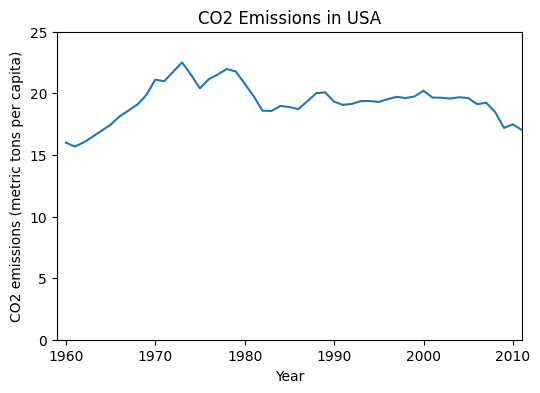

In [ ]:
#get the years.
#Note: Using .to_numpy() will return this as a numpy array rather than as a series, this can be better for plotting.
years = stage.Year.to_numpy()
#get the values
co2 = stage.Value.to_numpy()

#make a line plot
plt.figure(figsize=(6,4))
plt.plot(years, co2)

# Label the axes
plt.xlabel('Year')
plt.ylabel(stage.IndicatorName.iloc[0])

#label the figure
plt.title('CO2 Emissions in USA')

plt.axis([1959,2011,0,25])

plt.show()

## Exercise 1:
Produce a line plot just like the one above, but for life expectancy at birth in the USA versus time. The indicator string that you can search on is "Life expectancy at birth, total". Follow the same procedures used to produce the line plot of CO2 emissions versus time that is shown above. Your answer should look like the answer1.png file that is included with the notebook zip file. Note that you can add the tick marks on the right side with "plt.tick_params(right=True)"

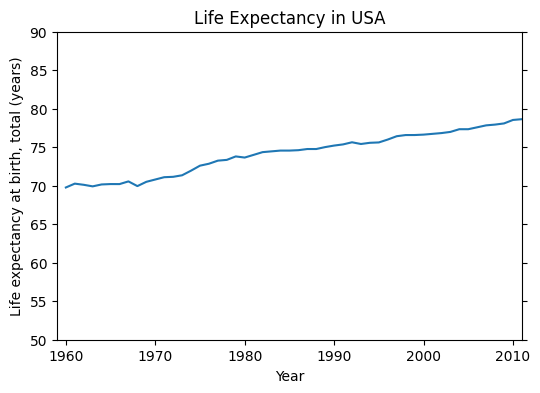

In [ ]:
### YOUR CODE HERE!
hist_indicator2 = 'Life expectancy at birth, total'
hist_country2 = 'USA'

mask3 = data.IndicatorName.str.contains(hist_indicator2)
mask4 = data.CountryCode.str.contains(hist_country2)

stage2 = data[mask3 & mask4]

years2 = stage2.Year.to_numpy()  #get years
life = stage2.Value.to_numpy()    #get life values

plt.figure(figsize=(6,4))
plt.plot(years2, life)

plt.xlabel('Year')
plt.ylabel(stage2.IndicatorName.iloc[0])

plt.title('Life Expectancy in USA')

plt.axis([1959,2011,50,90])

plt.tick_params(right=True)

plt.show()



### YOUR PLOT HERE!

## Using Histograms to explore the distribution of values
We could also visualize this data as a histogram to better explore the ranges of values in CO2 production per year.

In [ ]:
hist_data = stage.Value.to_numpy()

In [ ]:
print(hist_data)

[15.99977916 15.68125552 16.0139375  16.48276215 16.96811858 17.45172525
 18.12107301 18.59831788 19.08938916 19.85794566 21.11125227 20.98020348
 21.74864198 22.51058213 21.50293038 20.40222407 21.15761537 21.53248401
 21.97300469 21.78043698 20.78648774 19.76676417 18.59049523 18.57154371
 18.97675027 18.88231274 18.72072272 19.35033442 20.01041341 20.07576978
 19.32336817 19.06223666 19.14555576 19.36346258 19.37655644 19.29565986
 19.52789051 19.71427574 19.6151546  19.74781478 20.20761476 19.65619321
 19.63919577 19.57623905 19.68358135 19.61027504 19.11613882 19.23746045
 18.48923375 17.1923791  17.48479218 17.02021634]


In [ ]:
print(len(hist_data))

52


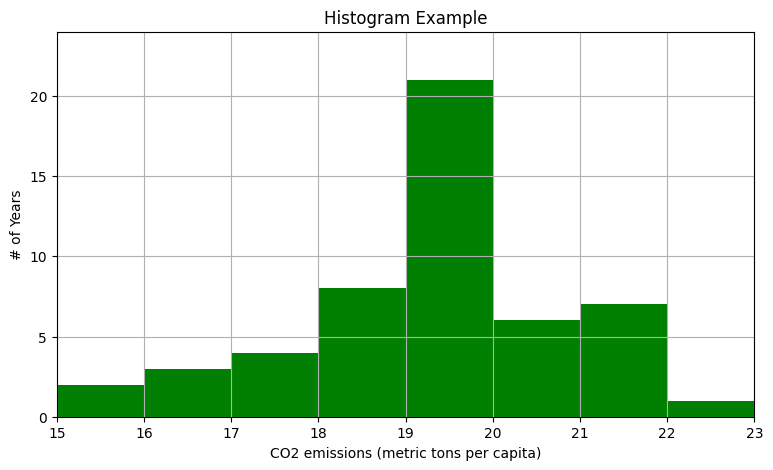

In [ ]:
# the histogram of the data
plt.figure(figsize=(9,5))

plt.hist(hist_data, bins=np.arange(15,24), density=False, facecolor='green')

plt.xlabel(stage.IndicatorName.iloc[0])
plt.ylabel('# of Years')
plt.title('Histogram Example')
plt.axis([15,23,0,24])

plt.grid(True)
plt.show()

So the USA has many years where it produced between 19-20 metric tons per capita with outliers on either side.

### But how do the USA's numbers relate to those of other countries?

In [ ]:
# select CO2 emissions for all countries in 2011
hist_indicator = 'CO2 emissions \(metric'
hist_year = 2011

mask1 = data.IndicatorName.str.contains(hist_indicator)
mask2 = data.Year == hist_year

# apply our mask
co2_2011 = data[mask1 & mask2]
co2_2011.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
5026275,Arab World,ARB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,4.724500
5026788,Caribbean small states,CSS,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,9.692960
5027295,Central Europe and the Baltics,CEB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,6.911131
5027870,East Asia & Pacific (all income levels),EAS,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,5.859548
5028456,East Asia & Pacific (developing only),EAP,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,5.302499


For how many countries do we have CO2 per capita emissions data in 2011

In [ ]:
print(len(co2_2011))

232


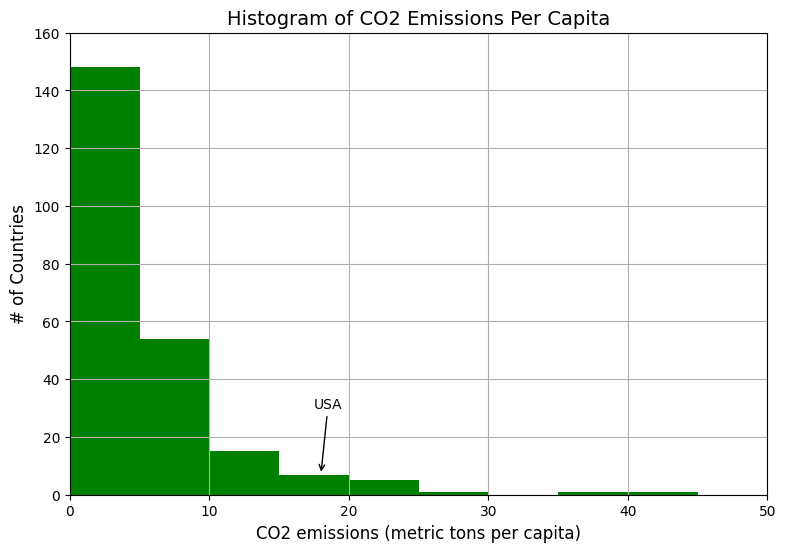

In [ ]:
# let's plot a histogram of the emissions per capita by country
# subplots returns a tuple with the figure, axis attributes.



fig, ax = plt.subplots(figsize=(9,6))

ax.annotate("USA",
            xy=(18, 7), xycoords='data',
            xytext=(17.5, 30), textcoords='data',
            arrowprops=dict(arrowstyle="->"))

plt.hist(co2_2011.Value.to_numpy(), bins=np.arange(0,55,5), density=False, facecolor='green')

plt.xlabel(co2_2011.IndicatorName.iloc[0],fontsize=12)
plt.ylabel('# of Countries',fontsize=12)
plt.title('Histogram of CO2 Emissions Per Capita',fontsize=14)

plt.axis([0, 50, 0, 160])
plt.grid(True)

plt.show()

So the USA, at ~17 CO2 emissions (metric tons per capital) is quite high among all countries.

An interesting next step would be to explore how this relates to other highly industrialized nations, and to look at the outliers with values over about 25.

## Exercise 2:
Produce a histogram like the one above, but for life expectancy at birth in the year **2013** for all countries. The indicator string that you can search on is "Life expectancy at birth, total". Follow the same procedures used to produce the histogram of CO2 emissions by country in 2011 that is shown above. Use bins that go in steps of five years from 40 to 90. You do not need to worry about putting on the arrow representing the USA, and thus you can just use the simple plt.figure syntax instead of the fig,ax =plt.subplots syntax. Your answer should look like the answer2.png file that is included with the notebook zip file.

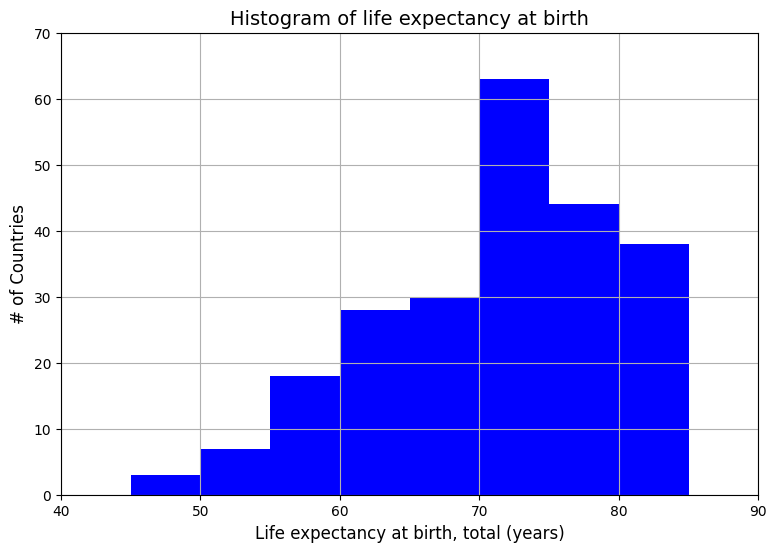

In [ ]:
### YOUR CODE HERE!

hist_indicator = 'Life expectancy at birth, total'
hist_year = 2013

mask1 = data.IndicatorName.str.contains(hist_indicator)
mask2 = data.Year == hist_year

# apply our mask
life_2013 = data[mask1 & mask2]
# life_2013.head()

fig, ax = plt.subplots(figsize=(9,6))

# ax.annotate("USA",
#             xy=(18, 7), xycoords='data',
#             xytext=(17.5, 30), textcoords='data',
#             arrowprops=dict(arrowstyle="->"))

plt.hist(life_2013.Value.to_numpy(), bins=np.arange(40,90,5), density=False, facecolor='blue')

plt.xlabel(life_2013.IndicatorName.iloc[0],fontsize=12)
plt.ylabel('# of Countries',fontsize=12)
plt.title('Histogram of life expectancy at birth',fontsize=14)

plt.axis([40, 90, 0, 70])
plt.grid(True)

plt.show()

### YOUR PLOT HERE!

## Relationship between GDP and CO2 Emissions in USA

In [ ]:
# select GDP Per capita emissions for the United States
hist_indicator = 'GDP per capita \(constant 2005'
hist_country = 'USA'

mask1 = data.IndicatorName.str.contains(hist_indicator)
mask2 = data.CountryCode.str.contains(hist_country)

gdp_stage = data[mask1 & mask2]

In [ ]:
gdp_stage.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
22282,United States,USA,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1960,15482.707760
48759,United States,USA,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1961,15578.409657
77142,United States,USA,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1962,16276.426685
105760,United States,USA,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1963,16749.789436
134798,United States,USA,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1964,17476.822248


### Inspect GDP versus time first.

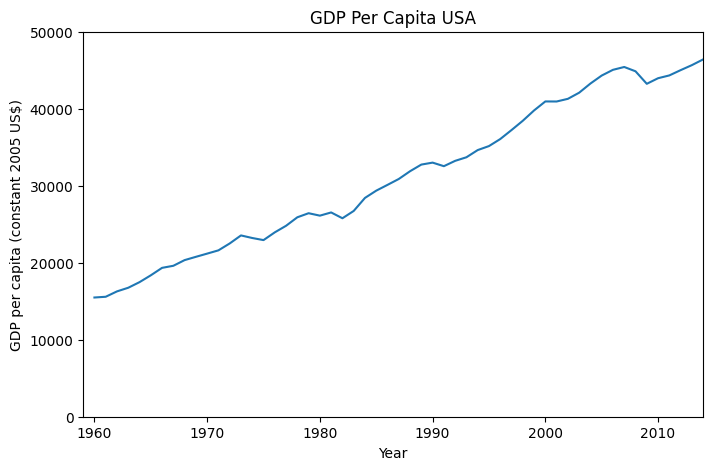

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(gdp_stage.Year.to_numpy(), gdp_stage.Value.to_numpy())

# Label the axes
plt.xlabel('Year')
plt.ylabel(gdp_stage.IndicatorName.iloc[0])

#label the figure
plt.title('GDP Per Capita USA')

plt.axis([1959,2014,0,50000])

plt.show()

## Scatter Plot for comparing GDP against CO2 emissions (per capita)

First, we'll need to make sure we're looking at the same time frames

In [ ]:
print("GDP Min Year = ", gdp_stage.Year.min(), "max: ", gdp_stage.Year.max())
print("CO2 Min Year = ", stage.Year.min(), "max: ", stage.Year.max())

GDP Min Year =  1960 max:  2014
CO2 Min Year =  1960 max:  2011


We have 3 extra years of GDP data, so let's trim those off so the scatterplot has equal length arrays to compare (this is actually required by scatterplot)

In [ ]:
gdp_stage_trunc = gdp_stage[gdp_stage.Year < 2012]
print(len(gdp_stage_trunc))
print(len(stage))

52
52


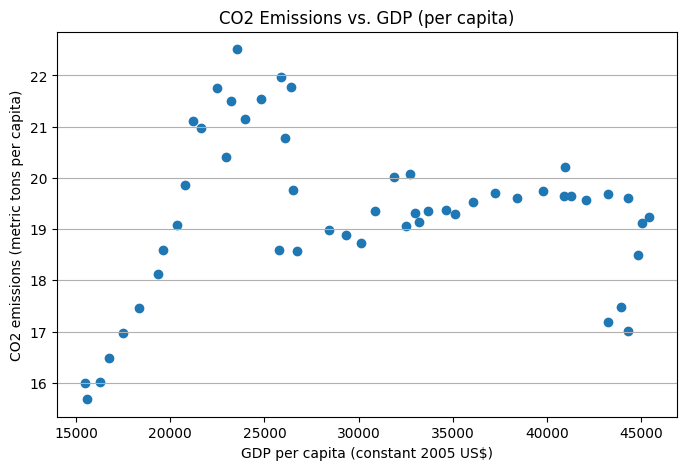

In [ ]:
plt.figure(figsize=(8,5))

x = gdp_stage_trunc.Value.to_numpy()
y = stage.Value.to_numpy()
plt.scatter(x, y)

plt.grid(True, axis='y')
plt.title('CO2 Emissions vs. GDP (per capita)',fontsize=12)
plt.xlabel(gdp_stage_trunc.IndicatorName.iloc[0],fontsize=10)
plt.ylabel(stage.IndicatorName.iloc[0],fontsize=10)

plt.show()

This doesn't look like a strong relationship.  We can test this by looking at correlation.

In [ ]:
np.corrcoef(x,y)

array([[1.        , 0.07676005],
       [0.07676005, 1.        ]])

A correlation of 0.07 is pretty weak, but you'll learn more about correlation later in this course.

You could continue to explore this to see if other countries have a closer relationship between CO2 emissions and GDP.  Perhaps it is stronger for developing countries?

## Exercise 3
Produce a scatter plot like the one above, but for life expectancy at birth versus GDP per capita in the United States. Follow the same procedures used to produce the scatter plot of CO2 emissions versus GDP per capita that is shown above. Note that you will have a mismatched number of years between life expectancy and GDP data, with life expectancy data going only to 2013. You can thus truncate the GDP data with a line like:<br> gdp_stage_trunc = gdp_stage\[gdp_stage.Year < 2014\]. Your answer should look like the answer3.png file that is included with the notebook zip file.

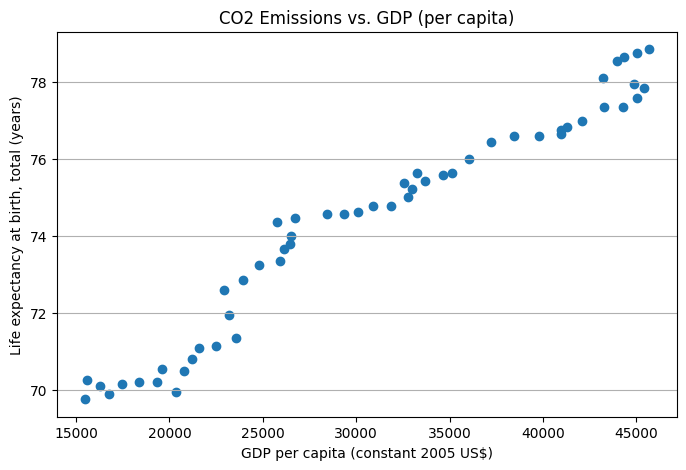

In [ ]:
### YOUR CODE HERE!

hist_indicator = 'GDP per capita \(constant 2005'
hist_country = 'USA'

mask1 = data.IndicatorName.str.contains(hist_indicator)
mask2 = data.CountryCode.str.contains(hist_country)

gdp_stage = data[mask1 & mask2]

gdp_stage_trunc = gdp_stage[gdp_stage.Year < 2014]

plt.figure(figsize=(8,5))

x = gdp_stage_trunc.Value.to_numpy()
y = stage2.Value.to_numpy()
plt.scatter(x, y)

plt.grid(True, axis='y')
plt.title('CO2 Emissions vs. GDP (per capita)',fontsize=12)
plt.xlabel(gdp_stage_trunc.IndicatorName.iloc[0],fontsize=10)
plt.ylabel(stage2.IndicatorName.iloc[0],fontsize=10)

plt.show()


### YOUR PLOT HERE!

## Want more ?

### Matplotlib Examples Library

https://matplotlib.org/stable/gallery/index.html